In [1]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel
from dataset import create_dataloaders
from data_split import create_train_val_split
from visualization import plot_training_curves

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3F789787-FE38-3CE7-8599-064BDD0416EE> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")


## Configuration Parameters


In [2]:
DATASET_NAME = "Lu"

In [3]:
TRAIN_PLOT_COLOR = '#2E86AB' 
VAL_PLOT_COLOR = '#A23B72'

In [4]:
# ========== Path Configuration ==========
PROJECT_ROOT = script_dir.parent.parent.parent
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_egemap_multi_seed"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EGEMAP_FEATURE_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_egemap_features"

# ========== Training Parameters ==========
MAX_EPOCHS = 50
LEARNING_RATE = 3e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 4
TRAIN_RATIO = 0.8
RANDOM_SEEDS = [21, 42, 84, 168, 336]
DATA_SPLIT_SEED = 42

## Step 1: Create Train/Val Split

In [5]:
# Use the create_train_val_split function with eGeMAPS mode
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    feature_dir_name=EGEMAP_FEATURE_DIR,
    train_ratio=TRAIN_RATIO,
    random_seed=DATA_SPLIT_SEED,
    dataset_name=DATASET_NAME,
    xlsr=False,  # eGeMAPS mode
    project_root=PROJECT_ROOT
)


============= Lu Train/Val Split Complete! =============
Training set: 42 samples (Control: 20, Dementia: 22)
Validation set: 11 samples (Control: 5, Dementia: 6)

Training CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemap-train.csv
Validation CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemap-val.csv


## Step 2: Extract eGeMAPS Features

In [6]:
import sys
from pathlib import Path

# extract_features.py is now in the same directory; import directly
from extract_egemap_feature import extract_features_from_csv

print("=" * 60)
print("Starting to extract eGeMAPS features...")
print("=" * 60)
print()

# Extract features for the training set
if TRAIN_CSV.exists():
    print("======== Extracting training set features ========")
    print(f"CSV path: {TRAIN_CSV}")
    print(f"Audio directory: {RAW_AUDIO_DIR}")
    extract_features_from_csv(TRAIN_CSV, raw_audio_dir=RAW_AUDIO_DIR, project_root=PROJECT_ROOT)
else:
    print(f"⚠️  Training CSV does not exist: {TRAIN_CSV}")
    print()

# Extract features for the validation set
if VAL_CSV.exists():
    print("======== Extracting validation set features ========")
    print(f"CSV path: {VAL_CSV}")
    print(f"Audio directory: {RAW_AUDIO_DIR}")
    extract_features_from_csv(VAL_CSV, raw_audio_dir=RAW_AUDIO_DIR, project_root=PROJECT_ROOT)
else:
    print(f"⚠️  Validation CSV does not exist: {VAL_CSV}")
    print()

2025-11-25 16:26:43 | INFO | numexpr.utils | NumExpr defaulting to 12 threads.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting to extract eGeMAPS features...

======== Extracting training set features ========
CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemap-train.csv
Audio directory: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/raw/Lu_merged
42 Audio Files



Extracting: 100%|██████████| 42/42 [00:35<00:00,  1.19it/s]



============= Extraction completed! =============
Successfully extracted: 42 个
Skipped: 0 个
Total: 42 个
======== Extracting validation set features ========
CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemap-val.csv
Audio directory: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/raw/Lu_merged
11 Audio Files



Extracting: 100%|██████████| 11/11 [00:09<00:00,  1.15it/s]


============= Extraction completed! =============
Successfully extracted: 11 个
Skipped: 0 个
Total: 11 个


## Step 3: Create Data Loaders


In [7]:
# Create data loaders
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, PROJECT_ROOT, 
    BATCH_SIZE, NUM_WORKERS
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

============= Creating training set (eGeMAPS features) =============
✅ Loading completed: 42 samples
   Control: 20, Dementia: 22

============= Creating validation set (eGeMAPS features) =============
✅ Loading completed: 11 samples
   Control: 5, Dementia: 6



## Step 4: Define Training Function and Model

In [8]:
class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = ADModel(DEFAULT_CONFIG)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(exist_ok=True)
    
    model = ADClassifier()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
    
    # 检测可用的加速器
    if torch.cuda.is_available():
        accelerator = 'gpu'
    elif torch.backends.mps.is_available():
        accelerator = 'mps'
    else:
        accelerator = 'cpu'
    
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)

    # Plot training curves using the visualization module
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color=TRAIN_PLOT_COLOR,
        val_color=VAL_PLOT_COLOR,
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss

### 1st Random Seed = 21

Seed set to 21
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 34: 100%|██████████| 2/2 [00:00<00:00, 74.33it/s, v_num=347, train_loss_step=0.482, train_acc_step=0.800, val_loss=0.499, val_acc=0.727, train_loss_epoch=0.276, train_acc_epoch=0.905] 


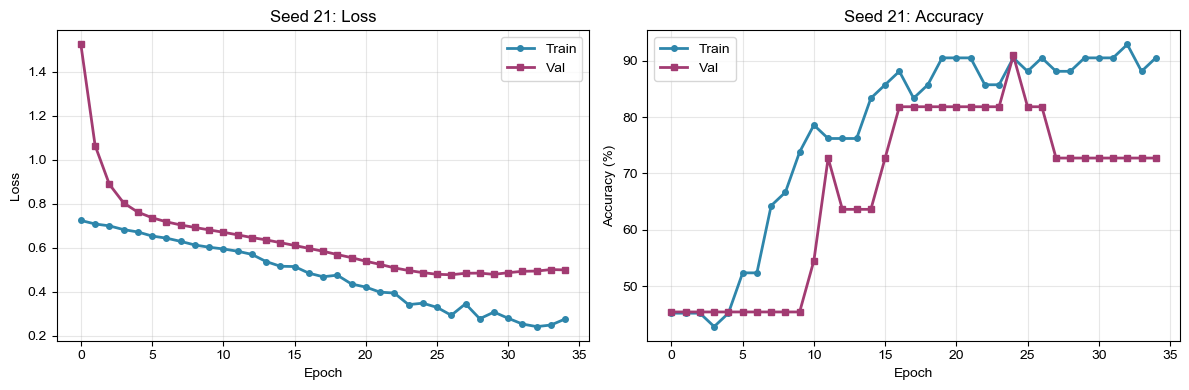

 Seed 21 : Val Acc = 90.91%, Val Loss = 0.4771


In [9]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 21: 100%|██████████| 2/2 [00:00<00:00, 74.98it/s, v_num=348, train_loss_step=0.326, train_acc_step=0.900, val_loss=0.448, val_acc=0.909, train_loss_epoch=0.318, train_acc_epoch=0.905] 


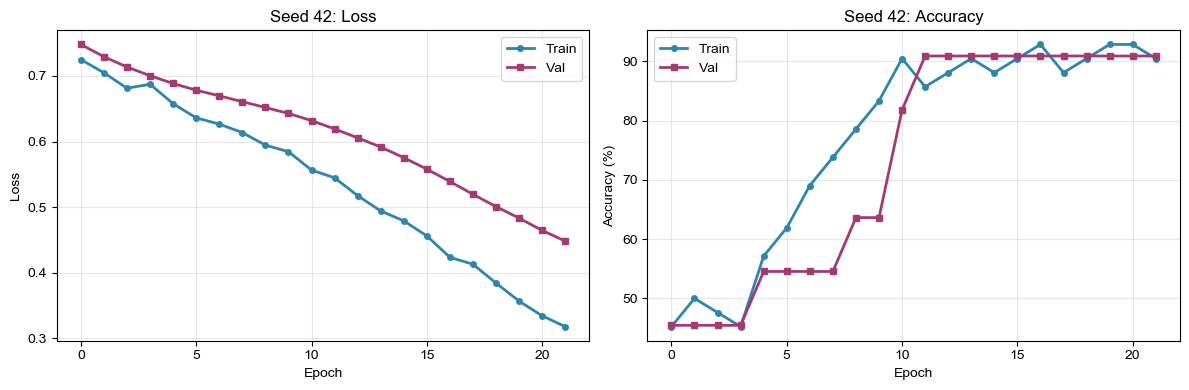

 Seed 42 : Val Acc = 90.91%, Val Loss = 0.4484


In [10]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84

Seed set to 84
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 29: 100%|██████████| 2/2 [00:00<00:00, 68.30it/s, v_num=349, train_loss_step=0.292, train_acc_step=0.800, val_loss=0.425, val_acc=0.909, train_loss_epoch=0.284, train_acc_epoch=0.833]  


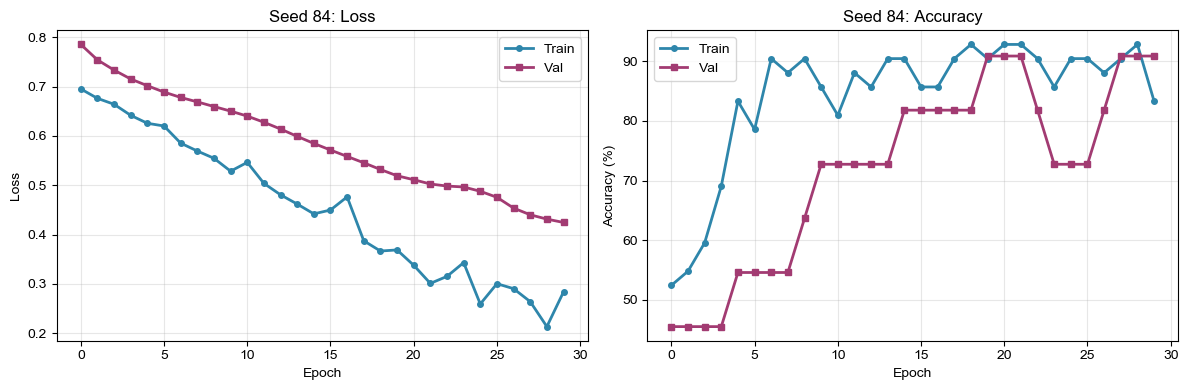

 Seed 84 : Val Acc = 90.91%, Val Loss = 0.4247


In [11]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168

Seed set to 168
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 22: 100%|██████████| 2/2 [00:00<00:00, 66.91it/s, v_num=350, train_loss_step=0.283, train_acc_step=0.900, val_loss=0.517, val_acc=0.818, train_loss_epoch=0.345, train_acc_epoch=0.857] 


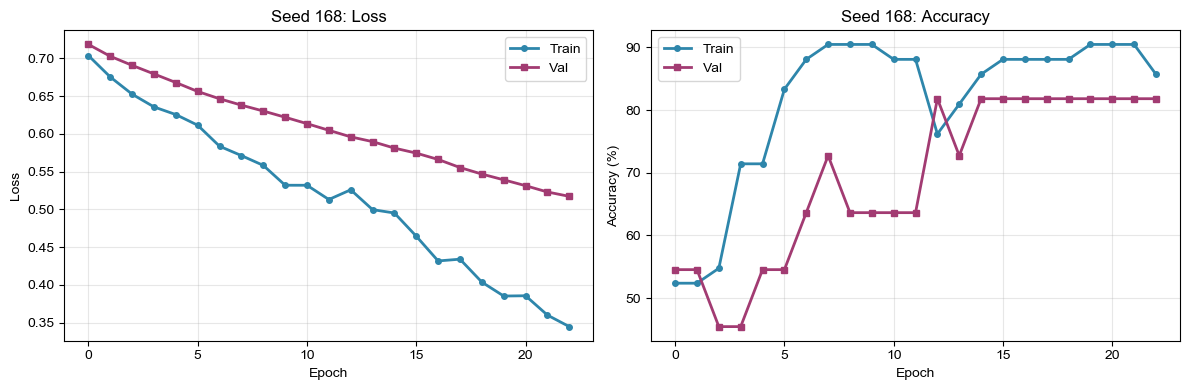

 Seed 168 : Val Acc = 81.82%, Val Loss = 0.5172


In [12]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336

Seed set to 336
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 30: 100%|██████████| 2/2 [00:00<00:00, 71.49it/s, v_num=351, train_loss_step=0.195, train_acc_step=0.900, val_loss=0.444, val_acc=0.909, train_loss_epoch=0.286, train_acc_epoch=0.881] 


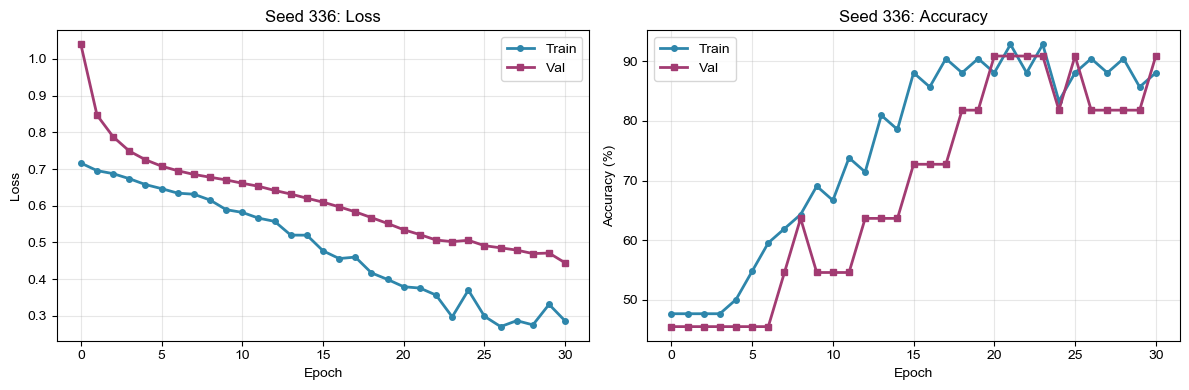

 Seed 336 : Val Acc = 90.91%, Val Loss = 0.4443


In [13]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [14]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")


Mean Validation Accuracy: 89.09%
Mean Validation Loss: 0.4623

Detailed Results:
  Seed 21: Acc=90.91%, Loss=0.4771
  Seed 42: Acc=90.91%, Loss=0.4484
  Seed 84: Acc=90.91%, Loss=0.4247
  Seed 168: Acc=81.82%, Loss=0.5172
  Seed 336: Acc=90.91%, Loss=0.4443
